# 4.3. Benchmarking: In-vitro Models

### 📘 Overview

This notebook benchmarks our DILI prediction model against 20+ industry-standard in vitro models, including a head-to-head comparison of predictive performance. It produces a comprehensive summary and generates the key figures used in the manuscript.

**Input**: 
* Results from DILImap and 20+ industry models

**Output**: 
* **Figure 6**
* **Industry Benchmark summary**

In [1]:
%%capture

!pip install adjustText

In [4]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import dilimap as dmap

In [5]:
dmap.logging.print_version()

Running dilimap 1.0.3 (python 3.10.16) on 2025-07-28 10:42.


## 1. Industry Benchmark

In [6]:
df = pd.read_excel(
    '../data/S4_DILImap_results.xlsx',
    sheet_name='INDUSTRY_BENCHMARK',
    header=22,
    index_col=0,
)

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [7]:
df.replace(0, np.nan, inplace=True)
df.replace({'DILI': True, 'No DILI': False, '+': True, '-': False}, inplace=True)

In [8]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
import pandas as pd

# Assume df is your DataFrame and 'DILI Label' contains the ground truth
y_true = df['DILI Label']
results = []

# Loop over all other columns (excluding metadata columns)
for col in df.iloc[:, 8:].columns:
    if col == 'DILI Label' or df[col].dropna().nunique() != 2:
        continue  # Skip ground truth and uninformative columns

    y_pred = df[col]

    # Drop rows where y_true or y_pred is NaN
    valid_idx = y_true.notna() & y_pred.notna()
    y_true_clean = y_true[valid_idx].astype(bool)
    y_pred_clean = y_pred[valid_idx].astype(bool)

    if len(y_true_clean) == 0:
        continue  # Skip if nothing left after filtering

    # Compute confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_true_clean, y_pred_clean, labels=[False, True]
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
    balanced_acc = balanced_accuracy_score(y_true_clean, y_pred_clean)

    results.append(
        {
            'Study': col,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'Balanced Accuracy': balanced_acc,
            'N': y_pred.notna().sum(),
        }
    )

# Convert to DataFrame
df_results = pd.DataFrame(results).sort_values('Balanced Accuracy', ascending=False)

In [9]:
# Drop suffixes and keep top performing entry per study
df_results['Study'] = df_results['Study'].str.replace(r'\s*[-–]\s*\d+$', '', regex=True)

df_results = df_results.groupby('Study', as_index=False).max()
df_results = df_results.sort_values('Balanced Accuracy', ascending=False)

df_results.loc[df_results['Study'] == 'Bergen 2024-DILImap', 'N'] = 300
df_results.loc[df_results['Study'] == 'Bergen 2024-validation', 'N'] = 300
df_results.loc[df_results['Study'] == 'Bergen 2024-TGP', 'N'] = 146
df_results['Study'] = df_results['Study'].str.split(r'\-').str[0]

In [10]:
df_results['Cell Model'] = (
    df_results['Study']
    .map(
        {
            'Fä 2025': '3D',
            'Ewart 2022': '3D',
            'Walker 2020': '3D',
            'Vorrink 2018': '3D',
            'Proctor 2017': '3D',
        }
    )
    .fillna('2D')
)

df_results['Assay'] = df_results['Study'].map(
    {
        'Fä 2025': 'Cytotoxicity',
        'Ewart 2022': 'Mechanistic',
        'Albrecht 2019': 'Cytotoxicity',
        'Bergen 2025': 'Toxicogenomics',
        'Walker 2020': 'Mechanistic',
        'Tolosa 2019': 'Mechanistic',
        'Vorrink 2018': 'Cytotoxicity',
        'Tolosa 2012': 'Mechanistic',
        'Aleo 2019': 'Mechanistic',
        'Persson 2013': 'Mechanistic',
        'Khetani 2012': 'Cytotoxicity',
        'Porceddu 2012': 'Other',
        'Dawson 2012': 'Other',
        'Schadt 2015': 'Mechanistic',
        'Kohonen 2017': 'Toxicogenomics',
        'Proctor 2017': 'Cytotoxicity',
        'Sakatis 2012': 'Other',
        'Xu  2008': 'Mechanistic',
        'Persson 2012': 'Mechanistic',
        'Gustafsson 2014': 'Cytotoxicity',
        "O'Brien 2006": 'Mechanistic',
        'Garside 2014': 'Mechanistic',
    }
)

In [11]:
def transparent_figure(nrows=1, ncols=1, figsize=(7, 5), dpi=120):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # transparent background
    fig.patch.set_alpha(0)
    ax.set_facecolor('none')
    return fig, ax

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


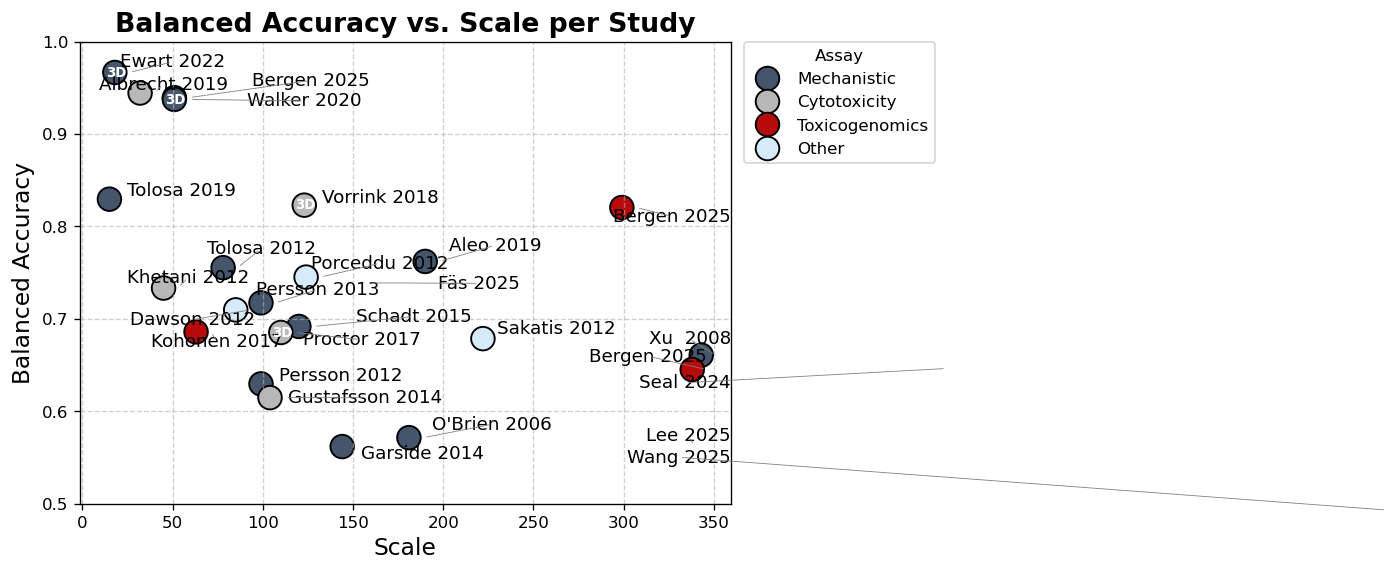

In [12]:
from adjustText import adjust_text

assay_palette = {
    'Toxicogenomics': '#b60a0b',
    'Mechanistic': '#45556c',
    'Cytotoxicity': '#b9b8b8',
    'Other': '#d6ebfa',
}

fig, ax = transparent_figure()

scatter = sns.scatterplot(
    data=df_results,
    x='N',
    y='Balanced Accuracy',
    hue='Assay',
    palette=assay_palette,
    s=200,
    edgecolor='black',
)

# Apply consistent rightward offset and anchor text to the left of it
texts = [
    plt.text(
        row['N'] + 8,  # x-offset: move label to the right
        row['Balanced Accuracy'],
        row['Study'],
        fontsize=11,
        va='center',
        ha='left',  # left-aligned text
    )
    for _, row in df_results.iterrows()
]

# Adjust only slightly to reduce overlap (disable arrows if not needed)
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_points=(2, 2),  # expand space around the point (x, y)
    expand_text=(1.5, 1.5),  # expand space around the text (x, y)
    force_text=0.2,  # stronger push between labels
    force_points=0.2,  # stronger push away from data points
)

for _, row in df_results[df_results['Cell Model'] == '3D'].iterrows():
    plt.text(
        row['N'] - 5,
        row['Balanced Accuracy'],
        '3D',
        color='white',
        weight='bold',
        fontsize=8,
        va='center',
        ha='left',
    )

plt.xlabel('Scale', fontsize=14)
plt.ylabel('Balanced Accuracy', fontsize=14)
plt.ylim(0.5, 1)
plt.title('Balanced Accuracy vs. Scale per Study', fontsize=16, weight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(title='Assay', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.show()

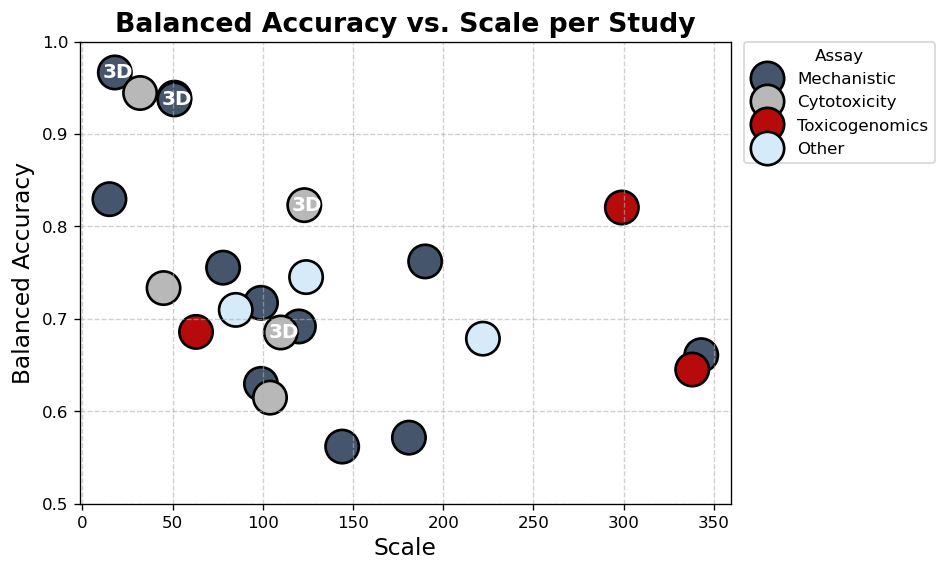

In [13]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

assay_palette = {
    'Toxicogenomics': '#b60a0b',
    'Mechanistic': '#45556c',
    'Cytotoxicity': '#b9b8b8',
    'Other': '#d6ebfa',
}

fig, ax = transparent_figure(figsize=(7, 5))

scatter = sns.scatterplot(
    data=df_results,
    x='N',
    y='Balanced Accuracy',
    hue='Assay',
    palette=assay_palette,
    s=400,
    edgecolor='black',
)

for _, row in df_results[df_results['Cell Model'] == '3D'].iterrows():
    plt.text(
        row['N'] - 7,
        row['Balanced Accuracy'],
        '3D',
        color='white',
        weight='bold',
        fontsize=12,
        va='center',
        ha='left',
    )

plt.xlabel('Scale', fontsize=14)
plt.ylabel('Balanced Accuracy', fontsize=14)
plt.ylim(0.5, 1)
plt.title('Balanced Accuracy vs. Scale per Study', fontsize=16, weight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(title='Assay', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.show()

In [14]:
df_results

,Study,Sensitivity,Specificity,Balanced Accuracy,N,Cell Model,Assay
6,Ewart 2022,0.933333,1.000000,0.966667,18,3D,Mechanistic
0,Albrecht 2019,1.000000,0.888889,0.944444,32,2D,Cytotoxicity
4,Bergen 2025,0.878788,1.000000,0.939394,51,2D,Toxicogenomics
24,Walker 2020,0.875000,1.000000,0.937500,51,3D,Mechanistic
22,Tolosa 2019,0.909091,0.750000,0.829545,15,2D,Mechanistic
23,Vorrink 2018,0.694915,0.951220,0.823067,123,3D,Cytotoxicity
2,Bergen 2025,0.762238,0.878788,0.820513,299,2D,Toxicogenomics
1,Aleo 2019,0.755102,0.865385,0.762166,190,2D,Mechanistic
21,Tolosa 2012,0.939394,0.571429,0.755411,78,2D,Mechanistic
16,Porceddu 2012,0.879310,0.611111,0.745211,124,2D,Other


## 2. Head-to-head comparison

In [15]:
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

ref_study = 'Bergen 2025-DILImap'
head2head_results = []
y_true = df['DILI Label']

for study in df.iloc[:, 8:].columns:
    if (
        'Bergen' in study
        or study in ['DILI Label', ref_study]
        or df[study].dropna().nunique() != 2
    ):
        continue  # skip ground truth and the reference itself

    y_pred = df[study]

    # Drop rows where y_true or y_pred is NaN
    valid_idx = y_true.notna() & y_pred.notna()
    y_true_clean = y_true[valid_idx].astype(bool)
    y_pred_clean = y_pred[valid_idx].astype(bool)

    if len(y_true_clean) == 0:
        continue  # Skip if nothing left after filtering

    # Compute confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_true_clean, y_pred_clean, labels=[False, True]
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float('nan')

    if True:  # specificity > 0.8:
        # Define valid overlap
        mask = df[ref_study].notna() & df[study].notna() & y_true.notna()
        if mask.sum() == 0:
            continue

        y_true_sub = df.loc[mask, 'DILI Label'].astype(bool)
        y_ref = df.loc[mask, ref_study].astype(bool)
        y_other = df.loc[mask, study].astype(bool)

        # Total positives/negatives
        n_pos = y_true_sub.sum()
        n_neg = (~y_true_sub).sum()

        # Correct predictions
        ref_pos = ((y_true_sub) & (y_ref)).sum()
        ref_neg = ((~y_true_sub) & (~y_ref)).sum()
        other_pos = ((y_true_sub) & (y_other)).sum()
        other_neg = ((~y_true_sub) & (~y_other)).sum()

        # Bergen balanced accuracy
        ref_tp = ref_pos
        ref_fn = n_pos - ref_tp
        ref_tn = ref_neg
        ref_fp = n_neg - ref_tn
        sens_ref = ref_tp / (ref_tp + ref_fn) if (ref_tp + ref_fn) > 0 else float('nan')
        spec_ref = ref_tn / (ref_tn + ref_fp) if (ref_tn + ref_fp) > 0 else float('nan')
        balanced_acc_ref = (
            (sens_ref + spec_ref) / 2
            if np.isfinite(sens_ref + spec_ref)
            else float('nan')
        )

        # Other balanced accuracy
        other_tp = other_pos
        other_fn = n_pos - other_tp
        other_tn = other_neg
        other_fp = n_neg - other_tn
        sens_other = (
            other_tp / (other_tp + other_fn)
            if (other_tp + other_fn) > 0
            else float('nan')
        )
        spec_other = (
            other_tn / (other_tn + other_fp)
            if (other_tn + other_fp) > 0
            else float('nan')
        )
        balanced_acc_other = (
            (sens_other + spec_other) / 2
            if np.isfinite(sens_other + spec_other)
            else float('nan')
        )

        # Apply specificity filter (for the "other" study)
        head2head_results.append(
            {
                'Study': study,
                'N overlap': mask.sum(),
                'Sensitivity (DILI+) Other': f'{round(other_pos / n_pos * 100) if n_pos > 0 else "-"}% ({other_pos} / {n_pos})',
                'Sensitivity (DILI+) Bergen': f'{round(ref_pos / n_pos * 100) if n_pos > 0 else "-"}% ({ref_pos} / {n_pos})',
                'Specificity (DILI-) Other': f'{round(other_neg / n_neg * 100) if n_neg > 0 else "-"}% ({other_neg} / {n_neg})',
                'Specificity (DILI-) Bergen': f'{round(ref_neg / n_neg * 100) if n_neg > 0 else "-"}% ({ref_neg} / {n_neg})',
                'BA Other': round(balanced_acc_other, 2),
                'BA Bergen': round(balanced_acc_ref, 2),
                'Overall Specificity Other': specificity,
            }
        )

    # Create table
    df_head2head = pd.DataFrame(head2head_results)

In [16]:
# in silico models
df_head2head[df_head2head.Study.isin(['Wang 2025', 'Lee 2025', 'Seal 2024'])]

,Study,N overlap,Sensitivity (DILI+) Other,Sensitivity (DILI+) Bergen,Specificity (DILI-) Other,Specificity (DILI-) Bergen,BA Other,BA Bergen,Overall Specificity Other
44,Wang 2025,97,63% (39 / 62),76% (47 / 62),57% (20 / 35),86% (30 / 35),0.60,0.81,0.372439
45,Lee 2025,8,100% (5 / 5),100% (5 / 5),67% (2 / 3),100% (3 / 3),0.83,1.00,0.274648
47,Seal 2024,30,100% (23 / 23),87% (20 / 23),14% (1 / 7),71% (5 / 7),0.57,0.79,0.404826


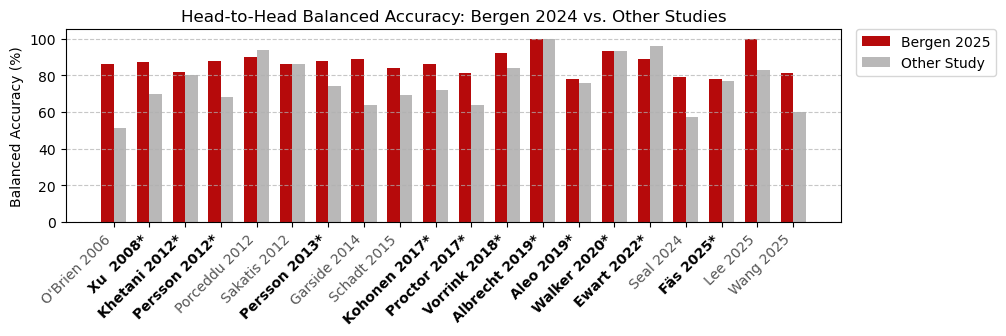

In [17]:
# Create DataFrame
df_balacc = df_head2head.copy()

df_balacc['Study'] = df_balacc['Study'].str.replace(r'\s*[-–]\s*\d+$', '', regex=True)
df_balacc = df_balacc[~df_balacc['Study'].str.startswith('Bergen')]
df_balacc = df_balacc.dropna()

# Keep only best study and sort by year
df_balacc['Year'] = df_balacc['Study'].str[-4:] + df_balacc['Study'].str[:-4]
df_balacc = df_balacc.sort_values('BA Other', ascending=False).drop_duplicates(
    subset='Study', keep='first'
)
df_balacc = df_balacc.sort_values('Year')

# Mark studies with >80% specificity
df_balacc['Study'] = df_balacc['Study'] + np.where(
    df_balacc['Overall Specificity Other'].astype(float) >= 0.8, '*', ''
)

# Bar plot
x = np.arange(len(df_balacc))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 2.5))

ax.bar(
    x - width / 2,
    df_balacc['BA Bergen'] * 100,
    width,
    label='Bergen 2025',
    color='#b60a0b',
)
ax.bar(
    x + width / 2,
    df_balacc['BA Other'] * 100,
    width,
    label='Other Study',
    color='#b9b8b8',
)

# Apply custom x-tick colors
xtick_labels = df_balacc['Study']
xtick_colors = ['black' if label.endswith('*') else '#555555' for label in xtick_labels]
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')
# for tick_label, color in zip(ax.get_xticklabels(), xtick_colors):
#    tick_label.set_color(color)

for tick_label, label in zip(ax.get_xticklabels(), xtick_labels):
    if label.endswith('*'):
        tick_label.set_color('black')
        tick_label.set_fontweight('bold')
    else:
        tick_label.set_color('#555555')

ax.set_ylabel('Balanced Accuracy (%)')
ax.set_title('Head-to-Head Balanced Accuracy: Bergen 2024 vs. Other Studies')
ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

if False:
    plt.xticks(x, df_balacc['Study'], rotation=45, ha='right')
    plt.ylabel('Balanced Accuracy (%)')
    plt.title('Head-to-Head Balanced Accuracy: Bergen 2024 vs. Other Studies')
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()

In [19]:
df_head2head

,Study,N overlap,Sensitivity (DILI+) Other,Sensitivity (DILI+) Bergen,Specificity (DILI-) Other,Specificity (DILI-) Bergen,BA Other,BA Bergen,Overall Specificity Other
0,O'Brien 2006,50,82% (37 / 45),71% (32 / 45),20% (1 / 5),100% (5 / 5),0.51,0.86,0.369565
1,Xu 2008,71,41% (27 / 66),74% (49 / 66),100% (5 / 5),100% (5 / 5),0.70,0.87,0.945205
2,Porceddu 2012-1,42,88% (36 / 41),80% (33 / 41),100% (1 / 1),100% (1 / 1),0.94,0.90,0.611111
3,Porceddu 2012-2,42,49% (20 / 41),80% (33 / 41),0% (0 / 1),100% (1 / 1),0.24,0.90,0.600000
4,Dawson 2012-1,30,53% (16 / 30),73% (22 / 30),-% (0 / 0),-% (0 / 0),NaN,NaN,0.882353
5,Dawson 2012-2,30,27% (8 / 30),73% (22 / 30),-% (0 / 0),-% (0 / 0),NaN,NaN,1.000000
6,Dawson 2012-3,30,47% (14 / 30),73% (22 / 30),-% (0 / 0),-% (0 / 0),NaN,NaN,0.941176
7,Dawson 2012-4,30,33% (10 / 30),73% (22 / 30),-% (0 / 0),-% (0 / 0),NaN,NaN,1.000000
8,Sakatis 2012-1,76,82% (53 / 65),72% (47 / 65),91% (10 / 11),100% (11 / 11),0.86,0.86,0.596154
9,Sakatis 2012-2,76,38% (25 / 65),72% (47 / 65),91% (10 / 11),100% (11 / 11),0.65,0.86,0.884615


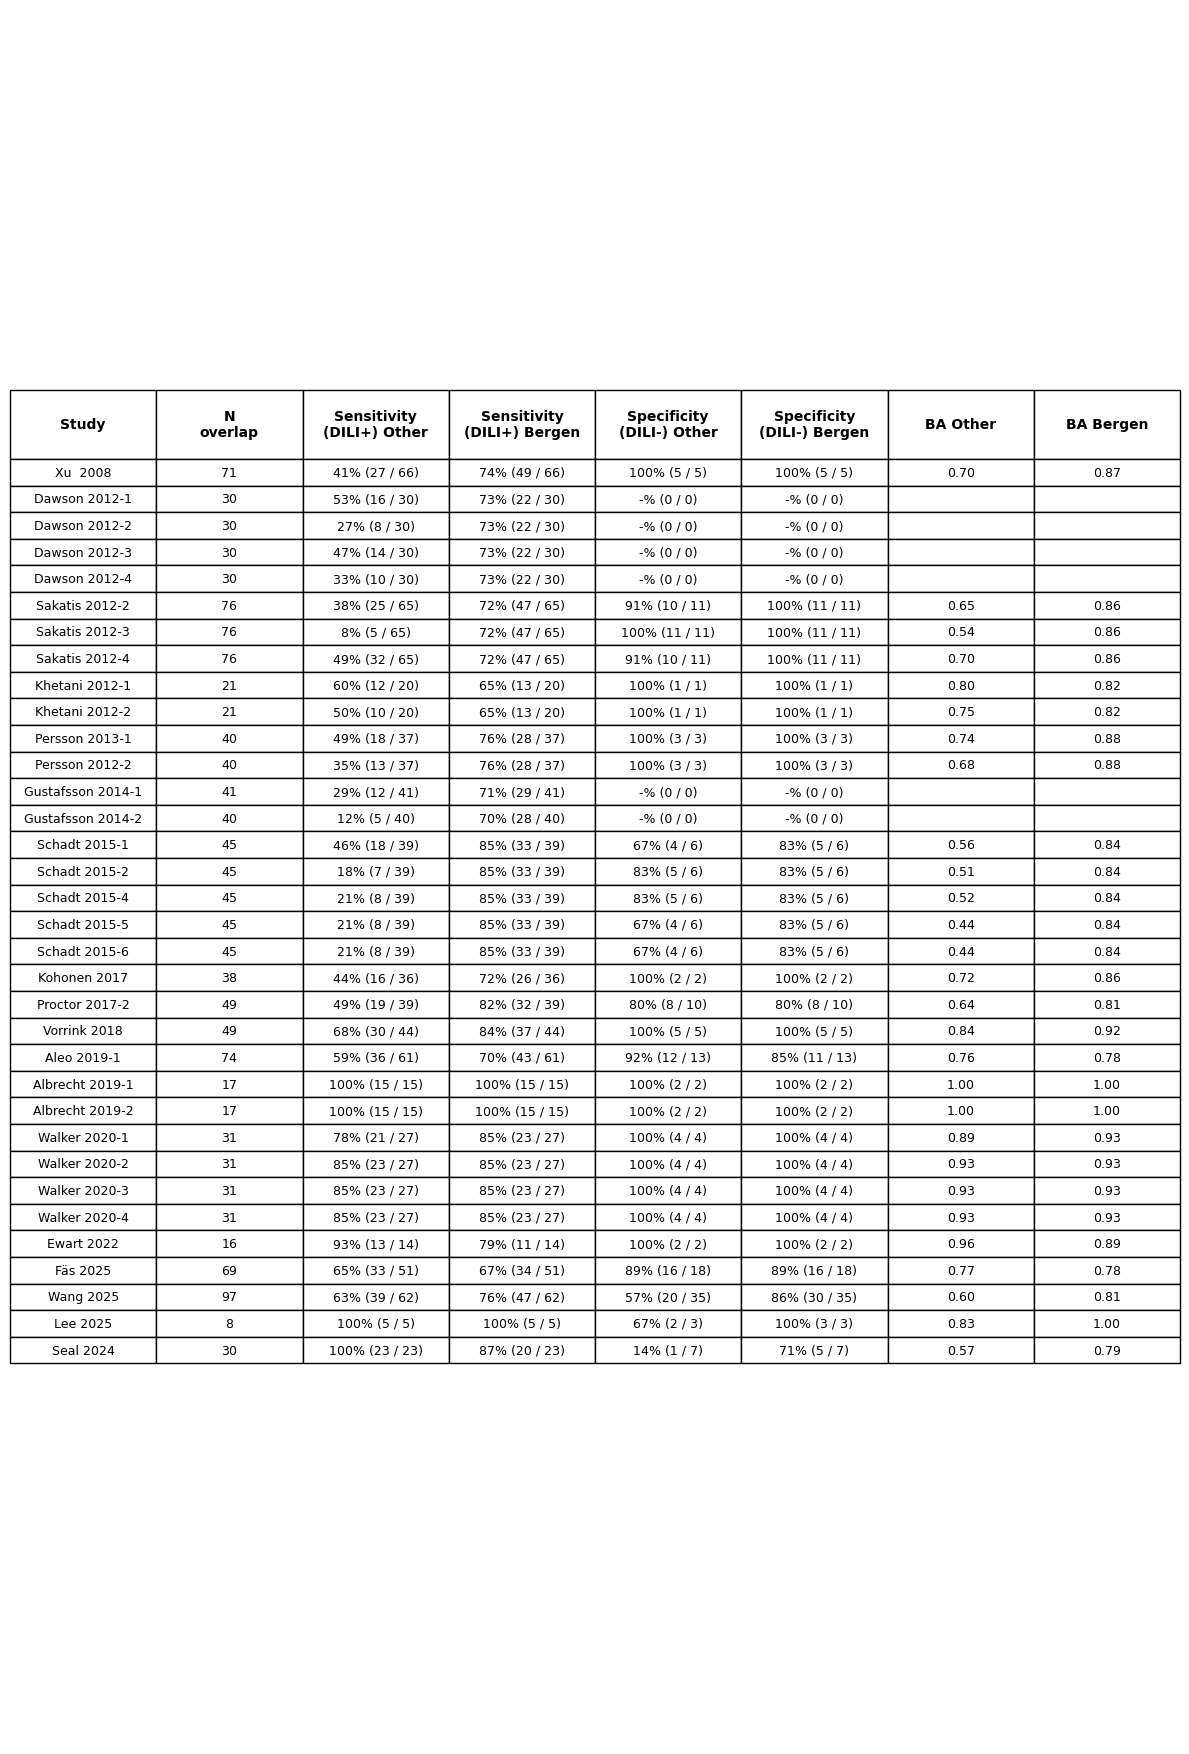

In [22]:
import matplotlib.pyplot as plt

# Define updated column labels with line breaks
col_labels = [
    'Study',
    'N\noverlap',
    'Sensitivity\n(DILI+) Other',
    'Sensitivity\n(DILI+) Bergen',
    'Specificity\n(DILI-) Other',
    'Specificity\n(DILI-) Bergen',
    'BA Other',
    'BA Bergen',
]

fig, ax = plt.subplots(
    figsize=(12, 0.5 + 0.35 * len(df_head2head))
)  # slightly taller rows
ax.axis('off')

# Copy and format float columns
df_table = df_head2head.copy()

df_table = df_table[
    (df_table['Overall Specificity Other'] > 0.8)
    | df_table.Study.isin(['Wang 2025', 'Lee 2025', 'Seal 2024'])
]
df_table.pop('Overall Specificity Other')

for col in df_table.select_dtypes(include=[float]).columns:
    df_table[col] = df_table[col].map(lambda x: f'{x:.2f}' if pd.notna(x) else '')

# Create table
table = ax.table(
    cellText=df_table.values.astype(str),
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)

# Styling
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.25)

# Header: increase font size, make bold, and expand row height
for key, cell in table.get_celld().items():
    row, col = key
    if row == 0:
        cell.set_fontsize(10)
        cell.set_text_props(weight='bold')
        cell.set_height(0.04)  # increase header height specifically

plt.tight_layout()
plt.show()

## Comparison with Vorrink's et al 3D model

In [15]:
df_cmpds = dmap.datasets.compound_DILI_labels()

df_cmpds.index = df_cmpds.index.str.lower()

Package: s3://dilimap/public/data. Top hash: e5bf3de9d2


In [16]:
study = 'Vorrink 2018'
ref_study = 'Bergen 2025-DILImap'

df_comp = df[~df[study].isna() & ~df[ref_study].isna()]

predicted_by_study = df_comp[
    df_comp['DILI Label'] & df_comp[study] & (df_comp[ref_study] == False)
]
predicted_by_ref = df_comp[
    df_comp['DILI Label'] & df_comp[ref_study] & (df_comp[study] == False)
]

In [17]:
print(f'Predicted by {study}:', set(predicted_by_study.index))
print(f'Predicted by {ref_study}:', set(predicted_by_ref.index))

Predicted by Vorrink 2018: {'trazodone', 'fialuridine', 'methotrexate'}
Predicted by Bergen 2025-DILImap: {'zileuton', 'phenytoin', 'propafenone', 'progesterone', 'labetalol', 'griseofulvin', 'fluconazole', 'temozolomide', 'albendazole', 'piroxicam'}


In [18]:
predicted_by_study['mechanism'] = df_cmpds.loc[predicted_by_study.index][
    'livertox_mechanism_summary'
]
predicted_by_study[
    [
        'DILIrank',
        'LiverTox',
        'idiosyncratic',
        'Predicted DILI in 2D',
        'Predicted DILI in 3D',
        'mechanism',
    ]
]

/var/folders/lz/prv79nmj5msg8h6nzqn0w7cw0000gn/T/ipykernel_76574/2095211378.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_by_study['mechanism'] = df_cmpds.loc[predicted_by_study.index][


,DILIrank,LiverTox,idiosyncratic,Predicted DILI in 2D,Predicted DILI in 3D,mechanism
Compound,,,,,,
methotrexate,Most-DILI-Concern,A,NaN,1 / 7,2 / 2,"Hepatitis, Steatosis, Fibrosis, Cirrhosis"
fialuridine,Most-DILI-Concern,NaN,NaN,1 / 3,3 / 3,NaN
trazodone,Less-DILI-Concern,B,NaN,3 / 3,1 / 1,"CYP, Cholestasis/Biliary, Immune-mediated, Hyp..."


In [19]:
predicted_by_ref['mechanism'] = df_cmpds.loc[predicted_by_ref.index][
    'livertox_mechanism_summary'
]
predicted_by_ref[
    [
        'DILIrank',
        'LiverTox',
        'idiosyncratic',
        'Predicted DILI in 2D',
        'Predicted DILI in 3D',
        'mechanism',
    ]
]

/var/folders/lz/prv79nmj5msg8h6nzqn0w7cw0000gn/T/ipykernel_76574/578130103.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_by_ref['mechanism'] = df_cmpds.loc[predicted_by_ref.index][


,DILIrank,LiverTox,idiosyncratic,Predicted DILI in 2D,Predicted DILI in 3D,mechanism
Compound,,,,,,
piroxicam,Less-DILI-Concern,B,NaN,1 / 5,0 / 1,"Hepatitis, Cholestasis/Biliary, Hypersensitivity"
zileuton,Most-DILI-Concern,D,NaN,3 / 6,1 / 2,"CYP, Immune-mediated, Hypersensitivity"
labetalol,Most-DILI-Concern,C,NaN,2 / 6,1 / 2,"Hepatitis, Immune-mediated, Hypersensitivity, ..."
fluconazole,Most-DILI-Concern,B,NaN,0 / 3,0 / 1,"CYP, Hypersensitivity"
progesterone,Less-DILI-Concern,A,NaN,0 / 3,0 / 1,NaN
phenytoin,Most-DILI-Concern,A,NaN,1 / 2,0 / 1,"CYP, Cholestasis/Biliary, Immune-mediated, Hyp..."
griseofulvin,Most-DILI-Concern,C,NaN,1 / 2,0 / 1,"Cholestasis/Biliary, Hypersensitivity"
temozolomide,Less-DILI-Concern,B,NaN,0 / 1,0 / 1,"Hepatitis, Necrosis, CYP, Cholestasis/Biliary,..."
albendazole,Most-DILI-Concern,B,NaN,1 / 1,0 / 1,"Hepatitis, Cholestasis/Biliary, Hypersensitivity"


## Comparison with Fä's et al 3D model

In [20]:
study = 'Fä 2025'
ref_study = 'Bergen 2025-DILImap'

df_comp = df[~df[study].isna() & ~df[ref_study].isna()]

predicted_by_study = df_comp[
    df_comp['DILI Label'] & df_comp[study] & (df_comp[ref_study] == False)
]
predicted_by_ref = df_comp[
    df_comp['DILI Label'] & df_comp[ref_study] & (df_comp[study] == False)
]

In [21]:
print(f'Predicted by {study}:', set(predicted_by_study.index))
print(f'Predicted by {ref_study}:', set(predicted_by_ref.index))

Predicted by Fä 2025: {'glafenine', 'haloperidol', 'fialuridine', 'erythromycin'}
Predicted by Bergen 2025-DILImap: {'propafenone', 'aspirin', 'fluconazole', 'ximelagatran', 'cimetidine'}


In [22]:
predicted_by_study['mechanism'] = df_cmpds.loc[predicted_by_study.index][
    'livertox_mechanism_summary'
]
predicted_by_study[
    [
        'DILIrank',
        'LiverTox',
        'idiosyncratic',
        'Predicted DILI in 2D',
        'Predicted DILI in 3D',
        'mechanism',
    ]
]

/var/folders/lz/prv79nmj5msg8h6nzqn0w7cw0000gn/T/ipykernel_76574/2095211378.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_by_study['mechanism'] = df_cmpds.loc[predicted_by_study.index][


,DILIrank,LiverTox,idiosyncratic,Predicted DILI in 2D,Predicted DILI in 3D,mechanism
Compound,,,,,,
erythromycin,Most-DILI-Concern,A,NaN,1 / 4,0 / 1,"Hepatitis, Cholestasis/Biliary, Hypersensitivity"
fialuridine,Most-DILI-Concern,NaN,NaN,1 / 3,3 / 3,NaN
glafenine,Most-DILI-Concern,NaN,NaN,2 / 4,0 / 1,Cirrhosis (manual annotation)
haloperidol,Less-DILI-Concern,B,NaN,1 / 3,0 / 0,"CYP, Cholestasis/Biliary, Steatosis, Hypersens..."


In [23]:
predicted_by_ref['mechanism'] = df_cmpds.loc[predicted_by_ref.index][
    'livertox_mechanism_summary'
]
predicted_by_ref[
    [
        'DILIrank',
        'LiverTox',
        'idiosyncratic',
        'Predicted DILI in 2D',
        'Predicted DILI in 3D',
        'mechanism',
    ]
]

/var/folders/lz/prv79nmj5msg8h6nzqn0w7cw0000gn/T/ipykernel_76574/578130103.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predicted_by_ref['mechanism'] = df_cmpds.loc[predicted_by_ref.index][


,DILIrank,LiverTox,idiosyncratic,Predicted DILI in 2D,Predicted DILI in 3D,mechanism
Compound,,,,,,
aspirin,Less-DILI-Concern,A [HD],NaN,1 / 8,1 / 1,"Hepatitis, Mitochondrial dysfunction, Steatosi..."
ximelagatran,Most-DILI-Concern,NaN,NaN,0 / 1,1 / 2,"Immune-mediated, Hypersensitivity, idiosyncrat..."
fluconazole,Most-DILI-Concern,B,NaN,0 / 3,0 / 1,"CYP, Hypersensitivity"
cimetidine,Less-DILI-Concern,B,NaN,1 / 3,0 / 0,"Necrosis, CYP, Cholestasis/Biliary, Immune-med..."
propafenone,Less-DILI-Concern,B,NaN,0 / 1,0 / 1,"Hepatitis, CYP, Cholestasis/Biliary, Immune-me..."
